# Optimizing Marker Expression for Late MgkPro.

## Prepare Notebook.

### Import the Libraries.

In [1]:
import os
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch

import sc_exp_design
import scopt

sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")

from experiment_utils import get_forward_model, generate_with_condition, generated_density_knn, get_adata_from_idx
from data_utils import (
    standardize_array_and_write_to_adata, get_condition_data_from_file,
    get_protocol_tranformations,
)
from inverse_utils import map_df, replace_silu_with_safe_silu

## Load Stuff.

### Load Configurations.

In [2]:
with hydra.initialize(
    config_path="../../config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
        ]
    )

/tmp/ipykernel_4090327/1109029905.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


### Load Prior Model.

In [3]:
# initialize prior models
prior_cfm = sc_exp_design.models.FlowMatchingWithScore.load(
    config.paths.prior_flow_path
)
prior_fm = sc_exp_design.models.FlowMap.load(
    config.paths.prior_flow_map_path
)
prior_cfm.velocity_field.eval()
prior_fm.flow_map.eval()

# show modules
print(prior_cfm.velocity_field)
print(prior_fm.flow_map)

NeuralVelocityFieldWithScore(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (resnet_blocks): ModuleList(
      (0-2): 3 x ResnetBlock(
        (net1): Sequential(
          (0): SiLU()
          (1): Linear(in_features=16, out_features=16, bias=True)
        )
        (cond_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=8, out_fe

### Load Forward Model.

In [4]:
forward_model, (
    phi_model,
    target_prediction_model
) = get_forward_model(config)
forward_model.target_prediction_model.resc_model["model"].eval()
forward_model.forward_model.velocity_field.eval()
print(forward_model.target_prediction_model.resc_model["model"])
print(forward_model.forward_model.velocity_field)

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=256, out_features=32, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=32, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)


### Patch Models for AD.

In [5]:
velocity_field_net = prior_cfm.velocity_field
flow_map_net = prior_fm.flow_map

replace_silu_with_safe_silu(velocity_field_net)
replace_silu_with_safe_silu(flow_map_net)

### Load Reference Media Concentrations.

In [6]:
condition_metadata_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/table_metadata_theis_unmix8.xlsx" 
protocol_data, condition_adata = get_condition_data_from_file(
    phi_model.data_manager,
    condition_metadata_path,
    config.annotation.protocol_columns,
    config.annotation.log1p_exp_cols,
    config.annotation.log21p_exp_cols,
    config.annotation.protocol_obs_key_added,
    config.annotation.protocol_sep,
    config.annotation.one_hot_uns_key_added,
    config.annotation.protocol_obsm_key,
)
condition_adata

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


{'gm-csf_[ng_ml]': <ufunc 'log1p'>, 'tpo_[ng_ml]': <ufunc 'log1p'>, 'sr1_[nm]': <ufunc 'log1p'>, 'um171_[nm]': <ufunc 'log1p'>, 'um729_[µm]': <ufunc 'log1p'>, 'scf_[ng_ml]': <ufunc 'log1p'>, 'butyzamide_[nm]': <ufunc 'log1p'>, 'retinoic_acid_[µm]': <ufunc 'log1p'>, 'ldl_[ng_ml]': <ufunc 'log1p'>, 'il3_[ng_ml]': <ufunc 'log1p'>, 'o2_[%]': <ufunc 'log1p'>, 'days_of_culture': <ufunc 'log1p'>}


100%|██████████| 12/12 [00:00<00:00, 727.27it/s]


AnnData object with n_obs × n_vars = 6 × 2
    obs: 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture'
    obsm: 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture', 'condition_concat'

### Read Original Annotation File.

In [7]:
experiment_id = "LPHO012"
additional_df_cols = ["experiment_number"]

condition_df = pd.read_excel(condition_metadata_path)
condition_df.columns = [col.replace("/", "_") for col in condition_df.columns]

all_df_cols = additional_df_cols + config.annotation.protocol_columns
lph_df = condition_df.loc[condition_df.experiment_id == experiment_id, all_df_cols]
lph_df

,experiment_number,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
262,205,10,2.5,750,560.0,0.0,10,0,0,0,0.0,20,14
263,206,10,2.5,375,560.0,0.0,10,0,0,0,0.0,20,14
264,207,10,2.5,75,560.0,0.0,10,0,0,0,0.0,20,14
265,208,10,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14
266,209,0,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14
267,210,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14


## Prepare Data.

### Concatenate Full Data.

In [8]:
# data for cellular response prediction model (full)
train_adata_phi = phi_model.train_data.adata
val_adata_phi = next(iter(phi_model.validation_data.values())).adata
adata_phi = sc.concat((train_adata_phi, val_adata_phi), uns_merge="same")
print(f"Full data shape: {adata_phi.shape}")

Full data shape: (52085765, 20)


### Concatenate Annotated Subset.

In [9]:
# data for classifier model (subset)
train_adata_g = target_prediction_model.train_data.adata
val_adata_g = target_prediction_model.validation_data.adata
adata_g = sc.concat((train_adata_g, val_adata_g), uns_merge="same")
print(f"Subset data shape: {adata_g.shape}")

Subset data shape: (471836, 20)


### Fit Label Encoder.

In [10]:
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()

## Get Target Values.

### Prepare Target Markers.

In [11]:
# get target markers
target_marker_names = [
    "CD41a",
    "CD56",
    "EPCR"
]
target_morph_feat_names = [
    # "SSC-A :: SSC - Area",
    # "FSC-A :: FSC - Area",
]
target_feat_names = target_marker_names + target_morph_feat_names

# get totality of features
all_feat_names = adata_phi.var_names.tolist() + config.annotation.scatter_columns
n_feats = len(all_feat_names)
n_channel_feats = adata_phi.shape[1]
n_scatter_feats = len(config.annotation.scatter_columns)

# define mask over target features only
target_feats_mask = [
    feat in target_feat_names for feat in all_feat_names
]

# get index per feature
# needed later to define the loss function
feat_name2target_index = {name: idx for idx, name in enumerate(target_feat_names)}
feat_name2orig_index = {
    name: all_feat_names.index(name) for name in target_feat_names
}

### Get Target Population.

In [12]:
target_ct = "late_MgkPro"
good_experiments = [210]  # or [210, 215, 220]
use_cell_type_filter = True   # set True to also require 'late_MgkPro'
keep_top_percentile = 25      # keep cells above this percentile for all markers

# Initial filter
ref_mask = adata_g.obs.experiment_number.isin(good_experiments)
if use_cell_type_filter:
    ref_mask = ref_mask & (adata_g.obs.cell_type == target_ct)
ref_adata = adata_g[ref_mask]

# Extract marker expression
marker_vals = ref_adata[:, target_marker_names].X
if hasattr(marker_vals, 'toarray'):
    marker_vals = marker_vals.toarray()

# Keep cells with all markers above percentile
thresholds = np.percentile(marker_vals, keep_top_percentile, axis=0)
keep_mask = np.all(marker_vals >= thresholds, axis=1)
ref_adata = ref_adata[keep_mask]

print(f"Final target population: {ref_adata.n_obs} cells")


Final target population: 1468 cells


### Visualize Selection Criteria.

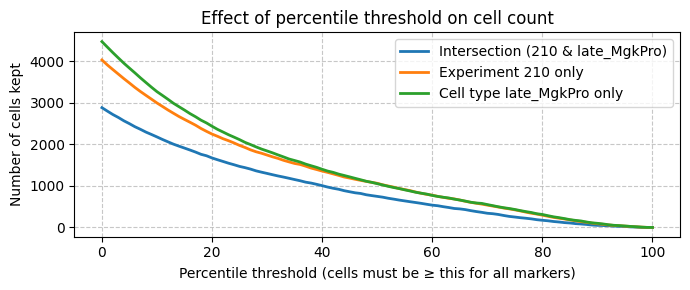

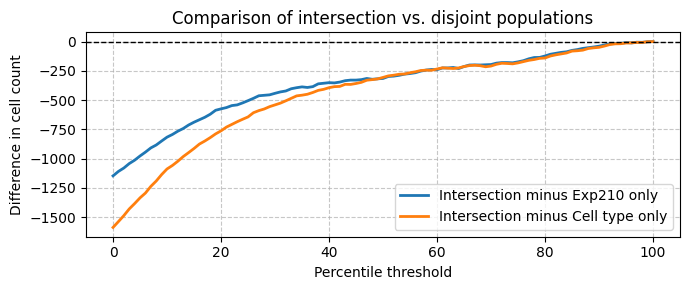

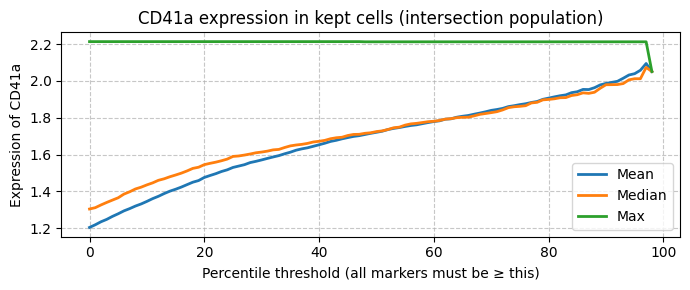

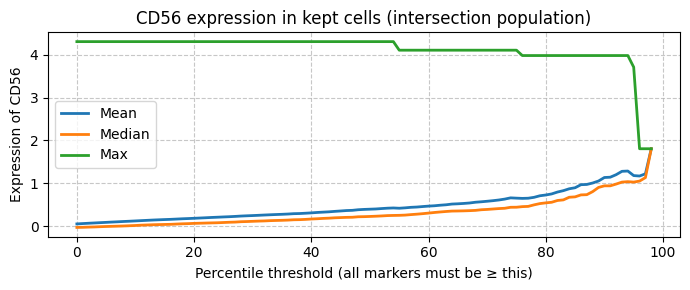

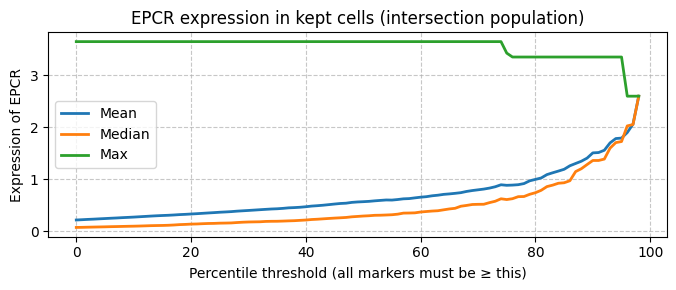


ACTUAL CELL COUNTS AT SELECTED PERCENTILES
Percentile |    Intersection |     Exp210 only |  Cell type only
----------------------------------------------------------------------
         0 |            2881 |            4029 |            4470
        25 |            1468 |            1973 |            2112
        50 |             747 |            1062 |            1053
        75 |             250 |             423 |             432
       100 |               0 |               0 |               0

DIFFERENCES (Intersection minus other)
Percentile |       Diff vs Exp210 |     Diff vs CellType
----------------------------------------------------------------------
         0 |                -1148 |                -1589
        25 |                 -505 |                 -644
        50 |                 -315 |                 -306
        75 |                 -173 |                 -182
       100 |                    0 |                    0

ACTUAL MEAN/MEDIAN/MAX EXPRESSION AT SELE

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. USER CONFIGURATION – ADAPT TO YOUR DATA
# ============================================================
target_ct = "late_MgkPro"
good_experiments = [210]          # only experiment 210 for the intersection
use_cell_type_filter = True       # kept for clarity, not directly used below

# Assume 'adata_g' is already loaded in the environment

# ============================================================
# 1. CREATE BOOLEAN MASKS FOR THE THREE POPULATIONS
# ============================================================
mask_exp210 = adata_g.obs.experiment_number.isin([210])
mask_celltype = adata_g.obs.cell_type == target_ct
mask_intersection = mask_exp210 & mask_celltype

populations = {
    "Intersection (210 & late_MgkPro)": mask_intersection,
    "Experiment 210 only": mask_exp210,
    "Cell type late_MgkPro only": mask_celltype,
}

# ============================================================
# 2. HELPER: count cells above all‑marker thresholds for a given percentile
# ============================================================
def count_above_percentile(mask, percentiles):
    """
    mask : boolean array (cells from adata_g)
    percentiles : list/array of percentiles (0..100)
    Returns array of counts, same length as percentiles.
    """
    sub = adata_g[mask]
    if sub.n_obs == 0:
        return np.zeros_like(percentiles, dtype=int)
    mat = sub[:, target_marker_names].X
    if hasattr(mat, "toarray"):
        mat = mat.toarray()
    counts = []
    for p in percentiles:
        thr = np.percentile(mat, p, axis=0)       # thresholds for each marker
        keep = np.all(mat >= thr, axis=1)         # cells above all thresholds
        counts.append(np.sum(keep))
    return np.array(counts)

# Percentile grid (0 to 100, step 1)
perc_range = np.linspace(0, 100, 101)

# Compute counts for each population
counts_dict = {}
for name, msk in populations.items():
    counts_dict[name] = count_above_percentile(msk, perc_range)

# ============================================================
# 3. PLOT 1: Number of kept cells vs percentile
# ============================================================
plt.figure(figsize=(7, 3))
for name, cnts in counts_dict.items():
    plt.plot(perc_range, cnts, label=name, linewidth=2)
plt.xlabel("Percentile threshold (cells must be ≥ this for all markers)")
plt.ylabel("Number of cells kept")
plt.title("Effect of percentile threshold on cell count")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ============================================================
# 4. PLOT 2: Difference between intersection and each disjoint population
# ============================================================
intersection_cnts = counts_dict["Intersection (210 & late_MgkPro)"]
exp_only_cnts = counts_dict["Experiment 210 only"]
ct_only_cnts = counts_dict["Cell type late_MgkPro only"]

plt.figure(figsize=(7, 3))
plt.plot(perc_range, intersection_cnts - exp_only_cnts,
         label="Intersection minus Exp210 only", linewidth=2)
plt.plot(perc_range, intersection_cnts - ct_only_cnts,
         label="Intersection minus Cell type only", linewidth=2)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel("Percentile threshold")
plt.ylabel("Difference in cell count")
plt.title("Comparison of intersection vs. disjoint populations")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ============================================================
# 5. PLOT 3: For each marker – mean, median, max in kept cells vs percentile
#    (only for the Intersection population)
# ============================================================
sub_int = adata_g[mask_intersection]
if sub_int.n_obs > 0:
    mat_int = sub_int[:, target_marker_names].X
    if hasattr(mat_int, "toarray"):
        mat_int = mat_int.toarray()
    
    n_markers = len(target_marker_names)
    # Store stats per marker: each is a list of length len(perc_range)
    marker_stats = {m: {"mean": [], "median": [], "max": []} for m in target_marker_names}
    
    for p in perc_range:
        thr = np.percentile(mat_int, p, axis=0)
        keep = np.all(mat_int >= thr, axis=1)
        if np.sum(keep) == 0:
            for m in target_marker_names:
                marker_stats[m]["mean"].append(np.nan)
                marker_stats[m]["median"].append(np.nan)
                marker_stats[m]["max"].append(np.nan)
        else:
            kept_mat = mat_int[keep, :]
            for i, m in enumerate(target_marker_names):
                marker_stats[m]["mean"].append(np.mean(kept_mat[:, i]))
                marker_stats[m]["median"].append(np.median(kept_mat[:, i]))
                marker_stats[m]["max"].append(np.max(kept_mat[:, i]))
    
    # Create a plot for each marker
    for m in target_marker_names:
        plt.figure(figsize=(7, 3))
        plt.plot(perc_range, marker_stats[m]["mean"], label="Mean", linewidth=2)
        plt.plot(perc_range, marker_stats[m]["median"], label="Median", linewidth=2)
        plt.plot(perc_range, marker_stats[m]["max"], label="Max", linewidth=2)
        plt.xlabel("Percentile threshold (all markers must be ≥ this)")
        plt.ylabel(f"Expression of {m}")
        plt.title(f"{m} expression in kept cells (intersection population)")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
else:
    print("Intersection population has zero cells – cannot plot marker statistics.")

# ============================================================
# 6. PRINT ACTUAL NUMBERS AT SELECTED PERCENTILES
# ============================================================
display_percentiles = [0, 25, 50, 75, 100]

print("\n" + "="*70)
print("ACTUAL CELL COUNTS AT SELECTED PERCENTILES")
print("="*70)
print(f"{'Percentile':>10} | {'Intersection':>15} | {'Exp210 only':>15} | {'Cell type only':>15}")
print("-"*70)
for p in display_percentiles:
    idx = np.where(perc_range == p)[0][0]
    int_cnt = counts_dict["Intersection (210 & late_MgkPro)"][idx]
    exp_cnt = counts_dict["Experiment 210 only"][idx]
    ct_cnt = counts_dict["Cell type late_MgkPro only"][idx]
    print(f"{p:10.0f} | {int_cnt:15d} | {exp_cnt:15d} | {ct_cnt:15d}")

print("\n" + "="*70)
print("DIFFERENCES (Intersection minus other)")
print("="*70)
print(f"{'Percentile':>10} | {'Diff vs Exp210':>20} | {'Diff vs CellType':>20}")
print("-"*70)
for p in display_percentiles:
    idx = np.where(perc_range == p)[0][0]
    diff_exp = intersection_cnts[idx] - exp_only_cnts[idx]
    diff_ct  = intersection_cnts[idx] - ct_only_cnts[idx]
    print(f"{p:10.0f} | {diff_exp:20d} | {diff_ct:20d}")

# Print marker expression stats for the intersection population
if sub_int.n_obs > 0:
    print("\n" + "="*80)
    print("ACTUAL MEAN/MEDIAN/MAX EXPRESSION AT SELECTED PERCENTILES")
    print("(Intersection population: exp210 & late_MgkPro)")
    print("="*80)
    for p in display_percentiles:
        idx = np.where(perc_range == p)[0][0]
        print(f"\n--- Percentile {p} ---")
        for m in target_marker_names:
            mean_val = marker_stats[m]["mean"][idx]
            med_val  = marker_stats[m]["median"][idx]
            max_val  = marker_stats[m]["max"][idx]
            # Use formatted printing; handle NaN
            print(f"{m:15s} : mean={mean_val}, "
                  f"median={med_val}, "
                  f"max={max_val}")

### Get Expression for Target Markers.

In [14]:
# query highest expression of marker in that group
def get_target_vals(ref_feat_values, target_type="max"):
    if target_type == "max":
        return np.max(ref_feat_values, axis=0, keepdims=True)
    elif target_type == "mean":
        return np.mean(ref_feat_values, axis=0, keepdims=True)
    elif target_type == "median":
        return np.median(ref_feat_values, axis=0, keepdims=True)
    elif target_type == "pop":
        return ref_feat_values
    else:
        raise ValueError

# get only target features
ref_channel_values = ref_adata[:, target_marker_names].X
ref_scatter_values = ref_adata.obs[target_morph_feat_names].values
ref_feat_values = np.concatenate((ref_channel_values, ref_scatter_values), axis=1)

# define target modes and get values
target_type_list = ["max", "median", "mean", "pop"]
target_type2vals = {
    target_type: get_target_vals(ref_feat_values, target_type=target_type)
    for target_type in target_type_list
}
target_adatas_dict = {}
feat_name2target_val = {}
target_type_2xstar = {}

for target_type, target_feature_values in target_type2vals.items():
    print("="*80)
    print(f"{target_feature_values.shape=}")

    # Prepare data matrix (will be (1, D) or (R, D))
    xstar_orig = np.zeros((target_feature_values.shape[0], n_feats), dtype=float)
    target_values_dict = {}

    for feat_name in target_feat_names:
        feat_idx = feat_name2target_index[feat_name]
        feat_orig_idx = feat_name2orig_index[feat_name]

        target_val = target_feature_values[..., feat_idx]   # (1,) or (R,)
        xstar_orig[..., feat_orig_idx] = target_val
        # For dict storage, convert scalar or array to a printable form
        if target_val.ndim == 0:
            target_values_dict[feat_name] = target_val.item()
        else:
            # For pop, store as array (or maybe mean/min/max for logging)
            target_values_dict[feat_name] = target_val.tolist()  # or keep as array
        print(f"Target type {target_type}: {feat_name} -> {target_val}")

    # Split into channel and scatter parts
    xstar_channel = xstar_orig[..., :n_channel_feats]      # (1, n_channel) or (R, n_channel)
    xstar_scatter = xstar_orig[..., n_channel_feats:]      # (1, n_scatter) or (R, n_scatter)

    # Build obs dictionary correctly
    n_obs = xstar_channel.shape[0]
    obs_dict = {}
    for idx, feat in enumerate(config.annotation.scatter_columns):
        values = xstar_scatter[..., idx]          # 1‑D array of length n_obs
        obs_dict[feat] = values                   # ✅ no extra list wrapping

    # Create AnnData
    target_adata = sc.AnnData(
        X=xstar_channel,
        obs=obs_dict,
        var=pd.DataFrame(index=adata_phi.var_names[:n_channel_feats])  # ensure correct length
    )

    target_adatas_dict[target_type] = target_adata
    target_type_2xstar[target_type] = xstar_orig
    feat_name2target_val[target_type] = target_values_dict


target_feature_values.shape=(1, 3)
Target type max: CD41a -> [2.21335888]
Target type max: CD56 -> [4.30681133]
Target type max: EPCR -> [3.64875746]
target_feature_values.shape=(1, 3)
Target type median: CD41a -> [1.58983743]
Target type median: CD56 -> [0.08588445]
Target type median: EPCR -> [0.15666433]
target_feature_values.shape=(1, 3)
Target type mean: CD41a -> [1.53000853]
Target type mean: CD56 -> [0.21587294]
Target type mean: EPCR -> [0.36671165]
target_feature_values.shape=(1468, 3)
Target type pop: CD41a -> [1.62294888 1.64011836 1.94058669 ... 1.78063381 1.81756699 1.42801464]
Target type pop: CD56 -> [ 0.28244451  0.00119644  0.93085247 ... -0.04566441  0.38121241
  0.02822913]
Target type pop: EPCR -> [0.03202558 0.54150409 0.19186176 ... 0.40165469 0.88653755 0.73053694]


### Prepare Representation.

In [15]:
print("="*80)
print("Standardizing Scatter Features.")
for target_type, target_adata in target_adatas_dict.items():
    X_scatter = target_adata.obs[config.annotation.scatter_columns].values
    target_adata = standardize_array_and_write_to_adata(
        target_adata, X_scatter, "X_scatter", params=train_adata_phi.uns["X_scatter_params"]
    )
    target_adatas_dict[target_type] = target_adata    
    print(f"{target_type}: -> {target_adata=}")

print("="*80)
print("Standardizing Channel Features.")
for target_type, target_adata in target_adatas_dict.items():
    X_channel = target_adata.X
    target_adata = standardize_array_and_write_to_adata(
        target_adata,
        X_channel,
        "X_channel",
        params=train_adata_phi.uns["X_channel_params"])
    target_adatas_dict[target_type] = target_adata
    print(f"{target_type}: -> {target_adata=}")

print("Creating joint representations.")
morphology_obsm_keys = ["X_scatter", "X_scatter_standardized"]
marker_expression_obsm_keys = ["X_channel", "X_channel_standardized"]
for target_type, target_adata in target_adatas_dict.items():
    print("="*80)
    for morph_key in morphology_obsm_keys:
        for mark_key in marker_expression_obsm_keys:
                target_adata.obsm[f"{mark_key}+{morph_key}"] = np.concatenate(
                    (target_adata.obsm[mark_key], target_adata.obsm[morph_key]), axis=-1
                )
    print(f"{target_type}: -> {target_adata=}")


Standardizing Scatter Features.
max: -> target_adata=AnnData object with n_obs × n_vars = 1 × 20
    obs: 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width'
    obsm: 'X_scatter', 'X_scatter_standardized'
median: -> target_adata=AnnData object with n_obs × n_vars = 1 × 20
    obs: 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width'
    obsm: 'X_scatter', 'X_scatter_standardized'
mean: -> target_adata=AnnData object with n_obs × n_vars = 1 × 20
    obs: 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width'
    obsm: 'X_scatter', 'X_scatter_standardized'
pop: -> target_adata=AnnData object with n_obs × n_vars = 1468 × 20
    obs: 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area

### Visualizing Resulting Targets After Transformation.

In [16]:
cell_state_rep_orig = "X_channel+X_scatter"
cell_state_rep_std = "X_channel_standardized+X_scatter_standardized"
for target_type, target_adata in target_adatas_dict.items():
    print(f"="*80)
    print(f"Target Type {target_type}")
    for idx, var_name in enumerate(all_feat_names):
        if var_name in target_feat_names:
            val_orig = target_adata.obsm[cell_state_rep_orig][:, idx].mean(0)
            val_std = target_adata.obsm[cell_state_rep_std][:, idx].mean(0)
            print(f"{var_name} -> Before {val_orig.item()}, Rescaled: {val_std.item()}")

Target Type max
CD41a -> Before 2.2133588790893555, Rescaled: 15.802325723579482
EPCR -> Before 3.6487574577331543, Rescaled: 29.828666958630702
CD56 -> Before 4.306811332702637, Rescaled: 27.72355534130182
Target Type median
CD41a -> Before 1.5898374319076538, Rescaled: 11.31408627338587
EPCR -> Before 0.15666433423757553, Rescaled: 0.7871179109650961
CD56 -> Before 0.0858844518661499, Rescaled: 0.8008073927168896
Target Type mean
CD41a -> Before 1.5300085296098154, Rescaled: 10.883425161777488
EPCR -> Before 0.36671164723326344, Rescaled: 2.5339497184137048
CD56 -> Before 0.2158729393707684, Rescaled: 1.6299255897634775
Target Type pop
CD41a -> Before 1.5300085296098154, Rescaled: 10.883425161777488
EPCR -> Before 0.36671164723326344, Rescaled: 2.5339497184137048
CD56 -> Before 0.2158729393707684, Rescaled: 1.6299255897634772


### Prepare Tensor Representations for Target States.

In [17]:
cell_state_rep = "X_channel_standardized+X_scatter_standardized"
device = "cuda"
dtype = torch.float32
xopt_dict_torch = {
    target_type: torch.from_numpy(target_adata.obsm[cell_state_rep]).\
        to(dtype).to(device)
    for target_type, target_adata in target_adatas_dict.items()
}
for target_type, xopt_torch in xopt_dict_torch.items():
    print(f"{target_type} -> {xopt_torch.shape}, {xopt_torch[:, target_feats_mask]}")


max -> torch.Size([1, 26]), tensor([[15.8023, 29.8287, 27.7236]], device='cuda:0')
median -> torch.Size([1, 26]), tensor([[11.3141,  0.7871,  0.8008]], device='cuda:0')
mean -> torch.Size([1, 26]), tensor([[10.8834,  2.5339,  1.6299]], device='cuda:0')
pop -> torch.Size([1468, 26]), tensor([[11.5524, -0.2494,  2.0545],
        [11.6760,  3.9876,  0.2606],
        [13.8389,  1.0798,  6.1903],
        ...,
        [12.6875,  2.8245, -0.0383],
        [12.9533,  6.8570,  2.6845],
        [10.1493,  5.5597,  0.4331]], device='cuda:0')


### Losses.

In [ ]:
import torch
import torch.nn.functional as F

# ------------------------------------------------------------------------------
#  L2 loss
# ------------------------------------------------------------------------------
def l2_loss(pred, target, feature_mask):
    """
    pred: (N, M, D)
    target: (1, D)
    """
    pred = pred.mean(-2) if pred.dim() == 3 else pred
    err = pred - target
    err = err[..., feature_mask]
    return torch.sum(err**2, dim=-1)


def l1_loss(pred, target, feature_mask):
    """
    pred: (N, M, D)
    target: (1, D)
    """
    pred = pred.mean(-2)
    err = pred - target
    err = err[..., feature_mask]
    return torch.sum(torch.abs(err), dim=-1)  # (N,)


def exp_loss(pred, target, feature_mask, sigma=1.0):
    """
    pred: (N, M, D)
    target: (1, D)
    """
    pred = pred.mean(-2)
    err = pred - target
    err = err[..., feature_mask]
    return 1 - torch.exp(-torch.sum(err, dim=-1)/(2*sigma**2))  # (N,)


def cauchy_loss(pred, target, feature_mask, gamma=1.0):
    """
    pred: (N, M, D)
    target: (1, D)
    """
    pred = pred.mean(-2)
    err = pred - target
    err = err[..., feature_mask]
    err = torch.sum((err/gamma)**2, dim=-1)
    return 0.5*torch.log(1 + err)


def hinge_loss(pred, target, feature_mask):
    """
    pred: (N, M, D)
    target: (1, D)
    """
    pred = pred.mean(-2)
    err = target - pred
    err = err[..., feature_mask]
    err = torch.nn.functional.relu(err)
    return torch.sum(err**2, dim=-1)

# ------------------------------------------------------------------------------
#  Energy distance (linear MMD)
# ------------------------------------------------------------------------------
def energy_distance(pred, ref, feature_mask, precomputed_within_ref=None, device='cuda'):
    """
    pred: (N, M, D)  predicted responses for N conditions, M forward passes
    ref:  (R, D)      reference population
    Returns: (N,)
    """
    if feature_mask is not None:
        pred = pred[..., feature_mask]
        ref = ref[..., feature_mask]

    N, M, D = pred.shape
    R = ref.shape[0]
    pred = pred.to(device)
    ref = ref.to(device)

    # Cross term: 2 * mean(||p - r||)
    cross_dist = torch.cdist(pred.view(N*M, D), ref)  # (N*M, R)
    cross_dist = cross_dist.view(N, M, R)
    cross_mean = cross_dist.mean(dim=(1, 2))           # (N,)

    # Within‑pred term
    within_pred = torch.zeros(N, device=device)
    for i in range(N):
        p = pred[i]
        pairwise = torch.cdist(p, p)
        mask = ~torch.eye(M, dtype=bool, device=device)
        within_pred[i] = pairwise[mask].mean()

    # Within‑ref term (constant)
    if precomputed_within_ref is None:
        pairwise_ref = torch.cdist(ref, ref)
        mask_ref = ~torch.eye(R, dtype=bool, device=device)
        within_ref = pairwise_ref[mask_ref].mean()
    else:
        within_ref = precomputed_within_ref

    return 2 * cross_mean - within_pred - within_ref   # (N,)

# ------------------------------------------------------------------------------
#  RBF‑MMD (unbiased estimator)
# ------------------------------------------------------------------------------
def rbf_mmd(pred, ref, feature_mask, sigma=None, device='cuda'):
    """
    pred: (N, M, D)
    ref:  (R, D)
    sigma: bandwidth (if None, use median heuristic)
    Returns: (N,) MMD² per condition
    """
    if feature_mask is not None:
        pred = pred[..., feature_mask]
        ref = ref[..., feature_mask]

    N, M, D = pred.shape
    R = ref.shape[0]
    pred = pred.to(device)
    ref = ref.to(device)

    # Flatten conditions for pairwise computation
    pred_flat = pred.view(N*M, D)   # (N*M, D)
    ref_flat = ref                   # (R, D)

    # Median heuristic for sigma if not provided
    if sigma is None:
        with torch.no_grad():
            # Sample a subset to compute median distance
            n_samples = min(1000, N*M, R)
            idx1 = torch.randperm(N*M)[:n_samples]
            idx2 = torch.randperm(R)[:n_samples]
            dists = torch.cdist(pred_flat[idx1], ref_flat[idx2])
            sigma = torch.median(dists).item() / np.sqrt(2)
            sigma = max(sigma, 1e-5)

    def kernel_matrix(X, Y, sigma):
        # Returns K where K[i,j] = exp(-||X[i] - Y[j]||² / (2σ²))
        dist = torch.cdist(X, Y) ** 2
        return torch.exp(-dist / (2 * sigma**2))

    # Unbiased MMD² = (1/(M(M-1))) Σ_{i≠j} k(p_i, p_j)
    #                + (1/(R(R-1))) Σ_{i≠j} k(r_i, r_j)
    #                - (2/(M R)) Σ_{i,j} k(p_i, r_j)
    mmd2 = torch.zeros(N, device=device)

    for i in range(N):
        p = pred[i]                     # (M, D)
        # Within‑pred (first term)
        k_pp = kernel_matrix(p, p, sigma)
        mask = ~torch.eye(M, dtype=bool, device=device)
        term1 = k_pp[mask].sum() / (M * (M - 1))

        # Within‑ref (second term) – same for all conditions, compute once
        if i == 0:
            k_rr = kernel_matrix(ref, ref, sigma)
            mask_ref = ~torch.eye(R, dtype=bool, device=device)
            term2_const = k_rr[mask_ref].sum() / (R * (R - 1))

        # Cross term (third term)
        k_pr = kernel_matrix(p, ref, sigma)   # (M, R)
        term3 = k_pr.mean() * 2               # 2 * mean over all M,R

        mmd2[i] = term1 + term2_const - term3

    return mmd2   # (N,)


### New Factory.


In [59]:
# ------------------------------------------------------------------------------
#  Loss factory
# ------------------------------------------------------------------------------
# def loss_fn_factory_new(
#     config,
#     target,                     # for L2: (1,D) or (D,); for MMD/energy: (R,D)
#     non_linearity,
#     cellular_response_model,
#     target_feats_mask,
#     loss_type='l2_mean',        # options: 'l2_mean', 'l2_cell', 'energy', 'rbf_mmd'
# ):
#     """
#     Returns (loss_fn, noise)
#     """
#     # Fixed noise if required
#     if config.loss_guidance.fix_noise:
#         noise = cellular_response_model.noise_distribution(
#             (config.sampling.N,
#              config.loss_guidance.num_forward_pass_per_sample,
#              cellular_response_model.velocity_field.config.flow_dim)
#         ).squeeze(dim=0).to(cellular_response_model.device)
#     else:
#         noise = None

#     # Pre‑compute constant for energy distance
#     pre_within_ref = None
#     if loss_type == 'energy':
#         ref_tensor = target if isinstance(target, torch.Tensor) else torch.tensor(target)
#         if target_feats_mask is not None:
#             ref_masked = ref_tensor[..., target_feats_mask].to(cellular_response_model.device)
#         else:
#             ref_masked = ref_tensor.to(cellular_response_model.device)
#         R = ref_masked.shape[0]
#         pairwise_ref = torch.cdist(ref_masked, ref_masked)
#         mask_ref = ~torch.eye(R, dtype=bool, device=ref_masked.device)
#         pre_within_ref = pairwise_ref[mask_ref].mean()

#     def _compute_loss(x1):
#         if non_linearity is not None:
#             x1 = non_linearity(x1)

#         batch_dict = {}
#         x1_fwd = x1
#         if noise is not None:
#             batch_dict[sc_exp_design.constants.DataFields.SOURCE_STATE] = noise
#             if config.loss_guidance.fix_noise:
#                 x1_fwd = x1.unsqueeze(1).repeat(1, noise.shape[1], 1)

#         condition_repr = next(iter(cellular_response_model.train_data.data.perturbation_covariates))
#         batch_dict[sc_exp_design.constants.DataFields.PERTURBATION_DATA] = {
#             condition_repr: x1_fwd
#         }

#         pred = cellular_response_model.predict(
#             batch_dict,
#             no_grad=False,
#             fix_noise=config.loss_guidance.fix_noise,
#             num_time_steps=config.loss_guidance.n_time_steps_forward_model,
#             solver_kwargs=config.loss_guidance.solver_kwargs_forward_model
#         )   # shape (N, M, D)

#         # Dispatch
#         if loss_type == 'l2_mean':
#             loss = l2_loss(pred, target, target_feats_mask, regress_mean=True)
#         elif loss_type == 'l2_cell':
#             loss = l2_loss(pred, target, target_feats_mask, regress_mean=False)
#         elif loss_type == 'energy':
#             loss = energy_distance(
#                 pred, target, target_feats_mask,
#                 precomputed_within_ref=pre_within_ref,
#                 device=cellular_response_model.device
#             )
#         elif loss_type == 'rbf_mmd':
#             loss = rbf_mmd(pred, target, target_feats_mask, device=cellular_response_model.device)
#         else:
#             raise ValueError(f"Unknown loss_type: {loss_type}")

#         return loss

#     return _compute_loss, noise

def loss_fn_factory_new(
    config,
    target,                     # for L2: (1,D) or (D,); for MMD/energy/pop: (R,D); for hinge: thresholds (D,)
    non_linearity,
    cellular_response_model,
    target_feats_mask,
    loss_type='l2_mean',        # options: 'l2_mean', 'l2_cell', 'energy', 'rbf_mmd', 'hinge', 'wasserstein'
    hinge_mode='above',         # 'above' or 'below' for hinge loss
):
    """
    Returns (loss_fn, noise)
    """
    # Fixed noise if required
    if config.loss_guidance.fix_noise:
        noise = cellular_response_model.noise_distribution(
            (config.sampling.N,
             config.loss_guidance.num_forward_pass_per_sample,
             cellular_response_model.velocity_field.config.flow_dim)
        ).squeeze(dim=0).to(cellular_response_model.device)
    else:
        noise = None

    # Pre‑compute constant for energy distance
    pre_within_ref = None
    if loss_type == 'energy':
        ref_tensor = target if isinstance(target, torch.Tensor) else torch.tensor(target)
        if target_feats_mask is not None:
            ref_masked = ref_tensor[..., target_feats_mask].to(cellular_response_model.device)
        else:
            ref_masked = ref_tensor.to(cellular_response_model.device)
        R = ref_masked.shape[0]
        pairwise_ref = torch.cdist(ref_masked, ref_masked)
        mask_ref = ~torch.eye(R, dtype=bool, device=ref_masked.device)
        pre_within_ref = pairwise_ref[mask_ref].mean()

    def _compute_loss(x1):
        if non_linearity is not None:
            x1 = non_linearity(x1)

        batch_dict = {}
        x1_fwd = x1
        if noise is not None:
            batch_dict[sc_exp_design.constants.DataFields.SOURCE_STATE] = noise
            if config.loss_guidance.fix_noise:
                x1_fwd = x1.unsqueeze(1).repeat(1, noise.shape[1], 1)

        condition_repr = next(iter(cellular_response_model.train_data.data.perturbation_covariates))
        batch_dict[sc_exp_design.constants.DataFields.PERTURBATION_DATA] = {
            condition_repr: x1_fwd
        }

        pred = cellular_response_model.predict(
            batch_dict,
            no_grad=False,
            fix_noise=config.loss_guidance.fix_noise,
            num_time_steps=config.loss_guidance.n_time_steps_forward_model,
            solver_kwargs=config.loss_guidance.solver_kwargs_forward_model
        )   # shape (N, M, D)

        # Dispatch
        if loss_type == 'l2_mean':
            loss = l2_loss(pred, target, target_feats_mask, regress_mean=True)
        elif loss_type == 'l1_mean':
            loss = l1_loss(pred, target, target_feats_mask, regress_mean=True)
        elif loss_type == 'exp_mean':
            loss = exp_loss(pred, target, target_feats_mask, regress_mean=True)
        elif loss_type == 'l2_cell':
            loss = l2_loss(pred, target, target_feats_mask, regress_mean=False)
        elif loss_type == 'l1_cell':
            loss = l1_loss(pred, target, target_feats_mask, regress_mean=False)
        elif loss_type == 'exp_cell':
            loss = exp_loss(pred, target, target_feats_mask, regress_mean=False)
        elif loss_type == 'energy':
            loss = energy_distance(
                pred, target, target_feats_mask,
                precomputed_within_ref=pre_within_ref,
                device=cellular_response_model.device
            )
        elif loss_type == 'rbf_mmd':
            loss = rbf_mmd(pred, target, target_feats_mask, device=cellular_response_model.device)
        elif loss_type == 'hinge':
            # target is expected to be thresholds (D,) or (1,D)
            loss = hinge_loss(pred, target, target_feats_mask, mode=hinge_mode)
        else:
            raise ValueError(f"Unknown loss_type: {loss_type}")

        return loss

    return _compute_loss, noise


### Old Factory.

In [60]:
def loss_fn_factory(
    config,
    optimal_condition,
    non_linearity,
    cellular_response_model,
    target_feats_mask,
    regress_mean=True,
):
    # sampling fixed noise for the forward model
    if config.loss_guidance.fix_noise:
        noise = cellular_response_model.noise_distribution(
            (
                config.sampling.N,
                config.loss_guidance.num_forward_pass_per_sample,
                cellular_response_model.velocity_field.config.flow_dim
            )
        ).squeeze(dim=0).to(cellular_response_model.device)
    else:
        noise = None

    def compute_target_loss(
            pred, # N, P, D
            target, # 1, D
            regress_mean=regress_mean,
        ): # -> N,
        """"""
        if regress_mean:
            pred = pred.mean(-2)
        else:
            target = target.unsqueeze(0)
        err = pred - target
        err = err[..., target_feats_mask]
        err_norm = torch.sum(err**2, dim=-1)
        if not regress_mean:
            return err_norm.mean(-1)
        return err_norm

    # function for computing loss from x_t
    def _compute_loss(x1):
        if non_linearity is not None:
            x1 = non_linearity(x1)
        batch_dict = {}
        x1_fwd = x1
        if noise is not None:
            batch_dict[sc_exp_design.constants.DataFields.SOURCE_STATE] = noise
            if config.loss_guidance.fix_noise:
                x1_fwd = x1.unsqueeze(1).repeat(1, config.loss_guidance.num_forward_pass_per_sample, 1)
        
        condition_repr = next(iter(cellular_response_model.train_data.data.perturbation_covariates))
        batch_dict[sc_exp_design.constants.DataFields.PERTURBATION_DATA] = {
            condition_repr: x1_fwd
        }
        pred = cellular_response_model.predict(
            batch_dict,
            no_grad=False,
            fix_noise=config.loss_guidance.fix_noise,
            num_time_steps=config.loss_guidance.n_time_steps_forward_model,
            solver_kwargs=config.loss_guidance.solver_kwargs_forward_model
        )
        phen_loss = compute_target_loss(pred, optimal_condition)
        return phen_loss
    return _compute_loss, noise


### Prepare Loss Functions for Target Types.

In [61]:
# use_new_factory = True                    # always True for the unified factory
# regress_mean = False                      # not used in new factory (specified via loss_type)
# non_linearity = torch.nn.ReLU()

# loss_type =  "hinge" # "l2_mean"
# loss_fn_dict = {}

# # --------------------------------------------------------------------------
# #  Point targets (L2)
# # --------------------------------------------------------------------------
# for target_type in ["max", "mean", "median",]:
#     xstar = target_type_2xstar[target_type]          # (1, D)
#     target_tensor = torch.tensor(xstar, dtype=torch.float32).to(device)

#     if use_new_factory:
#         loss_fn, noise = loss_fn_factory_new(
#             config,
#             target=target_tensor,
#             non_linearity=non_linearity,
#             cellular_response_model=phi_model,
#             target_feats_mask=target_feats_mask,
#             loss_type=loss_type,                     # or 'l2_cell'
#             # loss_type='l2_mean',                     # or 'l2_cell'
#         )
#     else:
#         # legacy – kept for compatibility
#         loss_fn, noise = loss_fn_factory(
#             config, target_tensor, non_linearity, phi_model,
#             target_feats_mask, regress_mean=regress_mean,
#         )
#     loss_fn_dict[target_type] = {"loss_fn": loss_fn, "noise": noise}

# # --------------------------------------------------------------------------
# #  Population target – Energy Distance and RBF‑MMD
# # --------------------------------------------------------------------------
# if "pop" in target_type_2xstar:
#     pop_matrix = target_type_2xstar["pop"]            # (R, D)
#     target_tensor = torch.tensor(pop_matrix, dtype=torch.float32).to(device)

#     # Energy distance
#     loss_fn_edist, noise_edist = loss_fn_factory_new(
#         config,
#         target=target_tensor,
#         non_linearity=non_linearity,
#         cellular_response_model=phi_model,
#         target_feats_mask=target_feats_mask,
#         loss_type='energy',
#     )
#     loss_fn_dict["pop-edist"] = {"loss_fn": loss_fn_edist, "noise": noise_edist}

#     # RBF‑MMD
#     loss_fn_mmd, noise_mmd = loss_fn_factory_new(
#         config,
#         target=target_tensor,
#         non_linearity=non_linearity,
#         cellular_response_model=phi_model,
#         target_feats_mask=target_feats_mask,
#         loss_type='rbf_mmd',
#     )
#     loss_fn_dict["pop-mmd"] = {"loss_fn": loss_fn_mmd, "noise": noise_mmd}




### Utility Functions to Instantiate Samplers.

In [62]:
# def sample_loss_guidance(
#     config,
#     loss_fn,
#     prior_cfm,
#     prior_fm,
#     solver_kwargs=None,
#     lmax=5e-0,
#     horizon=5e-0,
#     use_egf=True,
# ):
#     # prepare solver kwargs
#     if solver_kwargs is None:
#         solver_kwargs = {}
#     solver_kwargs.setdefault("method", "euler")
#     solver_kwargs.setdefault("atol", 5e-5)
#     solver_kwargs.setdefault("rtol", 5e-5)

#     # prepare time rescaling and posterior sampler
#     if not use_egf:
#         lgf = scopt.methods.LossGuidedFlow(
#             loss_fn,
#             prior_cfm,
#             scheduler=scopt.schedulers.ReciprocalGuidanceStrength(lmax=lmax),
#             flow_map=prior_fm,
#         )

#     else:
#         lgf = scopt.methods.EGFGuidedFlow(
#             loss_fn,
#             prior_cfm,
#             prior_fm,
#             scheduler=scopt.schedulers.LinearWarping(horizon=horizon),
#         )

#     # sample
#     lgf_sampling_traj = lgf.sample(
#         config.sampling.N,
#         num_time_steps=config.sampling.num_time_steps,
#         solver_kwargs=solver_kwargs,
#     ).detach().cpu().numpy()
#     torch.cuda.empty_cache()
#     return lgf_sampling_traj[-1]

# def sample_wgf_guidance_with_traj(
#     config,
#     loss_fn,
#     prior_cfm,
#     prior_fm,
#     solver_kwargs=None,
#     estimator="hutch-rademacher",
#     gamma=2.0,
#     horizon=0.1,
#     use_flow_map_score_estimator=False,
#     use_langevin=False,
#     return_loss_history=False,
# ):
#     if solver_kwargs is None:
#         solver_kwargs = {}
#     solver_kwargs.setdefault("method", "euler")
#     solver_kwargs.setdefault("atol", 5e-5)
#     solver_kwargs.setdefault("rtol", 5e-5)

#     time_warping = scopt.schedulers.LinearWarping(horizon=horizon)
#     wgf = scopt.methods.ULAGuidedFlow(
#         loss_fn,
#         prior_cfm,
#         flow_map=prior_fm,
#         scheduler=time_warping,
#         gamma=gamma,
#         estimator=estimator,
#         use_flow_map_score_estimator=use_flow_map_score_estimator,
#         use_langevin=use_langevin,
#     )

#     traj = wgf.sample(
#         config.sampling.N,
#         num_time_steps=config.sampling.num_time_steps,
#         solver_kwargs=solver_kwargs,
#     ).detach().cpu().numpy()
#     torch.cuda.empty_cache()

#     if not return_loss_history:
#         return traj[-1]

#     T = traj.shape[0] - 1
#     times = np.linspace(0.0, 1.0, T+1)
#     loss_history = []
#     for t_idx, t in enumerate(times):
#         x_t = torch.from_numpy(traj[t_idx]).to(prior_cfm.device)
#         with torch.no_grad():
#             x_1 = prior_fm(x_t, t)
#         loss_vals = loss_fn(x_1).detach().cpu().numpy()
#         loss_history.append(loss_vals)

#     return traj, loss_history


# def sample_wgf_guidance(
#     config,
#     loss_fn,
#     prior_cfm,
#     prior_fm,
#     solver_kwargs=None,
#     estimator = "hutch-rademacher",
#     gamma = 2.0,
#     horizon = .1,
#     use_flow_map_score_estimator=False,
#     use_langevin=False,
# ):

#     # prepare time rescaling and posterior sampler
#     time_warping = scopt.schedulers.LinearWarping(horizon=horizon)
#     wgf = scopt.methods.ULAGuidedFlow(
#         loss_fn,
#         prior_cfm,
#         flow_map=prior_fm,
#         scheduler=time_warping,
#         gamma=gamma,
#         estimator=estimator,
#         use_flow_map_score_estimator=use_flow_map_score_estimator,
#         use_langevin=use_langevin,
#     )

#     wgf_sampling_traj = wgf.sample(
#         config.sampling.N,
#         num_time_steps=config.sampling.num_time_steps,
#         solver_kwargs=solver_kwargs,
#     ).detach().cpu().numpy()
#     torch.cuda.empty_cache()
#     return wgf_sampling_traj[-1]



In [63]:
def sample_loss_guidance(
    config,
    loss_fn,
    prior_cfm,
    prior_fm,
    solver_kwargs=None,
    lmax=5e0,
    horizon=1e0,
    use_egf=True,
    return_loss_history=False,
):
    if solver_kwargs is None:
        solver_kwargs = {}
    solver_kwargs.setdefault("method", "euler")
    solver_kwargs.setdefault("atol", 5e-5)
    solver_kwargs.setdefault("rtol", 5e-5)

    if not use_egf:
        lgf = scopt.methods.LossGuidedFlow(
            loss_fn,
            prior_cfm,
            scheduler=scopt.schedulers.ReciprocalGuidanceStrength(lmax=lmax),
            flow_map=prior_fm,
        )
    else:
        lgf = scopt.methods.EGFGuidedFlow(
            loss_fn,
            prior_cfm,
            prior_fm,
            scheduler=scopt.schedulers.LinearWarping(horizon=horizon),
        )

    full_traj = lgf.sample(
        config.sampling.N,
        num_time_steps=config.sampling.num_time_steps,
        # num_time_steps=100,
        solver_kwargs=solver_kwargs,
    ).detach().cpu().numpy()   # (T+1, N, D)
    torch.cuda.empty_cache()

    if not return_loss_history:
        return full_traj[-1]

    T = full_traj.shape[0] - 1
    times = np.linspace(0.0, 1.0, T+1)   # uniform time steps
    loss_history = []

    for t_idx, t in enumerate(times):
        x_t = torch.from_numpy(full_traj[t_idx]).to(prior_cfm.device)   # (N, D)
        t_tensor = torch.full((x_t.shape[0],), t, device=prior_cfm.device)
        t_target = torch.ones_like(t_tensor)   # target time = 1
        with torch.no_grad():
            x_1 = prior_fm.flow_map(t_tensor, t_target, x_t)   # (N, D)
        loss_vals = loss_fn(x_1).detach().cpu().numpy()         # (N,)
        loss_history.append(loss_vals)

    return full_traj, loss_history

def sample_wgf_guidance(
    config,
    loss_fn,
    prior_cfm,
    prior_fm,
    solver_kwargs=None,
    estimator="hutch-rademacher",
    gamma=2.0,
    horizon=0.1,
    use_flow_map_score_estimator=False,
    use_langevin=False,
    return_loss_history=False,          # NEW argument
):
    # prepare solver kwargs
    if solver_kwargs is None:
        solver_kwargs = {}
    solver_kwargs.setdefault("method", "euler")
    solver_kwargs.setdefault("atol", 5e-5)
    solver_kwargs.setdefault("rtol", 5e-5)

    time_warping = scopt.schedulers.LinearWarping(horizon=horizon)
    wgf = scopt.methods.ULAGuidedFlow(
        loss_fn,
        prior_cfm,
        flow_map=prior_fm,
        scheduler=time_warping,
        gamma=gamma,
        estimator=estimator,
        use_flow_map_score_estimator=use_flow_map_score_estimator,
        use_langevin=use_langevin,
    )

    full_traj = wgf.sample(
        config.sampling.N,
        num_time_steps=config.sampling.num_time_steps,
        solver_kwargs=solver_kwargs,
    ).detach().cpu().numpy()   # shape (T+1, N, D)
    torch.cuda.empty_cache()

    if not return_loss_history:
        return full_traj[-1]   # final samples only

    # Compute loss history by mapping each intermediate state to t=1
    T = full_traj.shape[0] - 1
    times = np.linspace(0.0, 1.0, T+1)
    loss_history = []
    for t_idx, t in enumerate(times):
        x_t = torch.from_numpy(full_traj[t_idx]).to(prior_cfm.device)
        t_tensor = torch.full((x_t.shape[0],), t, device=prior_cfm.device)
        t_target = torch.ones_like(t_tensor)
        with torch.no_grad():
            x_1 = prior_fm.flow_map(t_tensor, t_target, x_t)
        loss_vals = loss_fn(x_1).detach().cpu().numpy()   # (N,)
        loss_history.append(loss_vals)

    return full_traj, loss_history

## Generate with Sakurai and Check Target Features.

### Generate with Condition Data.

In [64]:
# X_medium_true = protocol_data["feats_condition_concat_condition_concat"][..., None, :]

# num_time_steps = 100
# solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}

# fwd_out_true = generate_with_condition(
#     X_medium_true,
#     forward_model,
#     num_time_steps,
#     solver_kwargs,
#     ct_le,
#     num_samples=None,
#     noise=None,
#     logger=None,
#     n_scatter_feats=6,
# )


# # plot
# X_true = adata_g.obsm[cell_state_rep]
# for idx in range(fwd_out_true["X"].shape[0]):
#     print(idx)
#     X_generated = fwd_out_true["X"][idx]
#     density = generated_density_knn(
#         X_true,
#         X_generated,
#         k=20,
#         bandwidth=None
#     )
#     adata_g.obs["density"] = density
#     sc.pl.embedding(adata_g, "umap", color=["density", "cell_type"] + target_feat_names, s=20, legend_loc="on data")

## Run Optimization (Loss Guidance).

### Sample from Loss Guided Flow in Each Case.

In [69]:
use_new_factory = True
# non_linearity = torch.nn.Identity()
non_linearity = torch.nn.SiLU()

# ----------------------------------------------------------------------
# 1. Extract reference population matrix (already in standardised space)
# ----------------------------------------------------------------------
if "pop" in target_type_2xstar:
    pop_matrix = target_type_2xstar["pop"]            # (R, D) original scale? Actually standardised already
    ref_tensor = torch.tensor(pop_matrix, dtype=torch.float32).to(device)

    # Compute mean and percentiles for regression targets
    ref_mean = ref_tensor.mean(dim=0, keepdim=True)          # (1, D)
    ref_threshold_75 = torch.quantile(ref_tensor, 0.75, dim=0, keepdim=True)   # (1, D)

# ----------------------------------------------------------------------
# 2. Population targets (distribution matching)
# ----------------------------------------------------------------------
loss_fn_dict = {}

if "pop" in target_type_2xstar:
    # Energy distance
    loss_fn, noise = loss_fn_factory_new(
        config,
        target=ref_tensor,
        non_linearity=non_linearity,
        cellular_response_model=phi_model,
        target_feats_mask=target_feats_mask,
        loss_type='energy',
    )
    loss_fn_dict["pop-edist"] = {"loss_fn": loss_fn, "noise": noise}

    # RBF‑MMD
    loss_fn, noise = loss_fn_factory_new(
        config,
        target=ref_tensor,
        non_linearity=non_linearity,
        cellular_response_model=phi_model,
        target_feats_mask=target_feats_mask,
        loss_type='rbf_mmd',
    )
    loss_fn_dict["pop-mmd"] = {"loss_fn": loss_fn, "noise": noise}

    # Wasserstein (Sinkhorn)
    loss_fn, noise = loss_fn_factory_new(
        config,
        target=ref_tensor,
        non_linearity=non_linearity,
        cellular_response_model=phi_model,
        target_feats_mask=target_feats_mask,
        loss_type='wasserstein',
    )
    loss_fn_dict["pop-wdist"] = {"loss_fn": loss_fn, "noise": noise}

# ----------------------------------------------------------------------
# 3. Regression targets (point / inequality)
# ----------------------------------------------------------------------
# l1_mean: match the mean of the reference population
loss_fn, noise = loss_fn_factory_new(
    config,
    target=ref_mean,
    non_linearity=non_linearity,
    cellular_response_model=phi_model,
    target_feats_mask=target_feats_mask,
    loss_type='l1_mean',
)
loss_fn_dict["reg-l1_mean"] = {"loss_fn": loss_fn, "noise": noise}

# l2_mean: match the mean of the reference population
loss_fn, noise = loss_fn_factory_new(
    config,
    target=ref_mean,
    non_linearity=non_linearity,
    cellular_response_model=phi_model,
    target_feats_mask=target_feats_mask,
    loss_type='l2_mean',
)
loss_fn_dict["reg-l2_mean"] = {"loss_fn": loss_fn, "noise": noise}

loss_fn, noise = loss_fn_factory_new(
    config,
    target=ref_mean,
    non_linearity=non_linearity,
    cellular_response_model=phi_model,
    target_feats_mask=target_feats_mask,
    loss_type='exp_mean',
)
loss_fn_dict["reg-exp_mean"] = {"loss_fn": loss_fn, "noise": noise}

# l2_cell (cell‑wise L2, mean over cells) – not usually needed, but included
loss_fn, noise = loss_fn_factory_new(
    config,
    target=ref_mean,
    non_linearity=non_linearity,
    cellular_response_model=phi_model,
    target_feats_mask=target_feats_mask,
    loss_type='l2_cell',
)
loss_fn_dict["reg-l2_cell"] = {"loss_fn": loss_fn, "noise": noise}

# l1_cell (cell‑wise L1, mean over cells) – not usually needed, but included
loss_fn, noise = loss_fn_factory_new(
    config,
    target=ref_mean,
    non_linearity=non_linearity,
    cellular_response_model=phi_model,
    target_feats_mask=target_feats_mask,
    loss_type='l1_cell',
)
loss_fn_dict["reg-l1_cell"] = {"loss_fn": loss_fn, "noise": noise}


loss_fn, noise = loss_fn_factory_new(
    config,
    target=ref_mean,
    non_linearity=non_linearity,
    cellular_response_model=phi_model,
    target_feats_mask=target_feats_mask,
    loss_type='exp_cell',
)
loss_fn_dict["reg-exp_cell"] = {"loss_fn": loss_fn, "noise": noise}
# hinge: encourage cells to be ABOVE the 75th percentile of the reference
loss_fn, noise = loss_fn_factory_new(
    config,
    target=ref_threshold_75,
    non_linearity=non_linearity,
    cellular_response_model=phi_model,
    target_feats_mask=target_feats_mask,
    loss_type='hinge',
    hinge_mode='above'
)
loss_fn_dict["reg-hinge"] = {"loss_fn": loss_fn, "noise": noise}

# ----------------------------------------------------------------------
# (Optional) Keep point targets from original data (max/mean/median)
# ----------------------------------------------------------------------
# If you still want the exact point targets (max/mean/median of individual cells),
# uncomment the following:
for target_type in ["max", "mean", "median"]:
    for loss_type in ["l1_cell", "l1_mean", "l2_cell", "l2_mean", "exp_mean", "exp_cell"]:
        xstar = target_type_2xstar[target_type]          # (1, D)
        target_tensor = torch.tensor(xstar, dtype=torch.float32).to(device)
        loss_fn, noise = loss_fn_factory_new(
            config, target_tensor, non_linearity, phi_model,
            target_feats_mask, loss_type=loss_type
        )
        loss_fn_dict[f"point_{target_type}_{loss_type}"] = {"loss_fn": loss_fn, "noise": noise}

In [70]:
loss_fn_dict.keys()

dict_keys(['pop-edist', 'pop-mmd', 'pop-wdist', 'reg-l1_mean', 'reg-l2_mean', 'reg-exp_mean', 'reg-l2_cell', 'reg-l1_cell', 'reg-exp_cell', 'reg-hinge', 'point_max_l1_cell', 'point_max_l1_mean', 'point_max_l2_cell', 'point_max_l2_mean', 'point_max_exp_mean', 'point_max_exp_cell', 'point_mean_l1_cell', 'point_mean_l1_mean', 'point_mean_l2_cell', 'point_mean_l2_mean', 'point_mean_exp_mean', 'point_mean_exp_cell', 'point_median_l1_cell', 'point_median_l1_mean', 'point_median_l2_cell', 'point_median_l2_mean', 'point_median_exp_mean', 'point_median_exp_cell'])

In [71]:
opt_samples_dict = {}
loss_history_dict = {}
# target_types_to_run = [ "point_max_l2_mean", "reg-exp_mean"]   # or e.g. ["max", "mean", "median", "pop"]
target_types_to_run = [ "point_max_l2_mean", ]   # or e.g. ["max", "mean", "median", "pop"]
# target_types_to_run = ["pop-edist"]   # or e.g. ["max", "mean", "median", "pop"]

for target_type, opt_dict in loss_fn_dict.items():
    if target_type not in target_types_to_run:
        continue
    print("="*80)
    print(f"Running Loss Guidance Optimization on Target Type: {target_type}")
    
    loss_fn = opt_dict["loss_fn"]
    
    # Initialize a sub-dictionary for this target type
    opt_samples_dict[target_type] = {}
    loss_history_dict[target_type] = {}
    
    # for use_egf in [False, True]:
    for use_egf in [False]:
        print(f"\n--- use_egf = {use_egf} ---")
        opt_traj, loss_history = sample_loss_guidance(
            config,
            loss_fn,
            prior_cfm,
            prior_fm,
            use_egf=use_egf,
            return_loss_history=True
        )

        # opt_traj, loss_history = sample_wgf_guidance(
        #     config,
        #     loss_fn,
        #     prior_cfm,
        #     prior_fm,
        #     return_loss_history=True
        # )
        opt_samples = opt_traj[-1]
        opt_samples_dict[target_type][use_egf] = opt_samples
        loss_history_dict[target_type][use_egf] = loss_history
        print(f"Optimization Finished (use_egf={use_egf}, opt_samples.shape={opt_samples.shape})")


Running Loss Guidance Optimization on Target Type: point_max_l2_mean

--- use_egf = False ---
Optimization Finished (use_egf=False, opt_samples.shape=(10, 12))


### Visualize loss history.

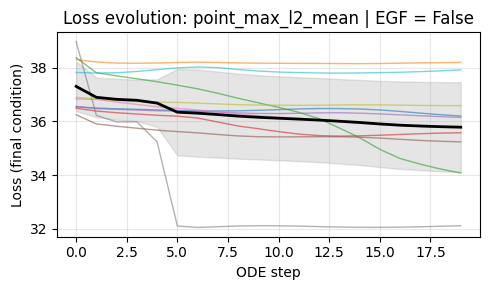

In [72]:
# ----------------------------------------------------------------------
# Plot loss evolution for each optimization run
# ----------------------------------------------------------------------
for target_type in target_types_to_run:
    for use_egf in [False, True]:
        if use_egf not in loss_history_dict[target_type]:
            continue
            
        loss_history = loss_history_dict[target_type][use_egf]
        # loss_history is a list of length (num_time_steps+1), each element a numpy array (N,)
        loss_arr = np.array(loss_history)   # shape (T+1, N)
        T = loss_arr.shape[0] - 1
        steps = np.arange(T+1)
        
        # Plot individual samples (first up to 10)
        plt.figure(figsize=(5, 3))
        N_samples = loss_arr.shape[1]
        for i in range(min(N_samples, 10)):
            plt.plot(steps, loss_arr[:, i], alpha=0.6, linewidth=1, label=f'Sample {i+1}')
        
        # Add mean ± std
        mean_loss = loss_arr.mean(axis=1)
        std_loss = loss_arr.std(axis=1)
        plt.plot(steps, mean_loss, 'k-', linewidth=2, label='Mean')
        plt.fill_between(steps, mean_loss - std_loss, mean_loss + std_loss, 
                         alpha=0.2, color='gray', label='±1 std')
        
        plt.xlabel('ODE step')
        plt.ylabel('Loss (final condition)')
        plt.title(f'Loss evolution: {target_type} | EGF = {use_egf}')
        # plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

### Visualize Generated Samples.

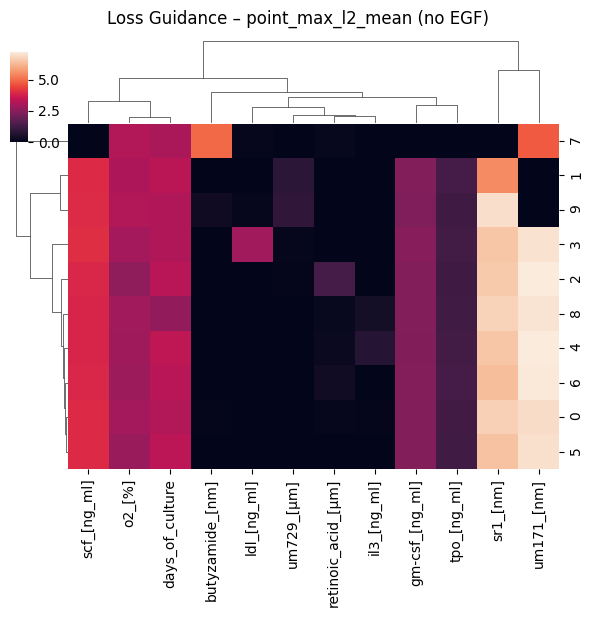

In [73]:
# Loop over target types and EGF modes
for target_type, egf_dict in opt_samples_dict.items():
    for use_egf, samples in egf_dict.items():
        # Clip negative values to 0 (optional)
        samples = np.maximum(samples, 0.0)
        
        # Create clustermap with original values
        try:
            g = sns.clustermap(
                samples,
                xticklabels=config.annotation.protocol_columns,
                figsize=(6, 6),
                cbar_pos=(0.02, 0.8, 0.03, 0.15),
                dendrogram_ratio=(0.1, 0.2),
            )
            egf_str = "with EGF" if use_egf else "no EGF"
            g.fig.suptitle(f"Loss Guidance – {target_type} ({egf_str})", y=1.02)
        except:
            plt.figure(figsize=(6, 6))
            g = sns.heatmap(
                samples,
                xticklabels=config.annotation.protocol_columns,
            )
        # Add title
        plt.show()


### Tranform Samples Back to their Original Scale.

In [74]:
opt_df_dict[('point_max', True)]

NameError: name 'opt_df_dict' is not defined

In [75]:
# get transformations
protocol_transf = get_protocol_tranformations(
    config.annotation.protocol_columns,
    log1p_exp_cols=config.annotation.log1p_exp_cols,
    log21p_exp_cols=config.annotation.log21p_exp_cols,
    inverse=True
)

raw_opt_df_dict = {}
opt_df_dict = {}

for target_type, egf_dict in opt_samples_dict.items():
    for use_egf, samples in egf_dict.items():
        samples = np.maximum(samples, 0)
        raw_opt_df = pd.DataFrame(samples, columns=config.annotation.protocol_columns)
        opt_df = map_df(raw_opt_df, protocol_transf)
        
        
        key = (target_type, use_egf)   # e.g., ('max', False)
        raw_opt_df_dict[key] = raw_opt_df
        opt_df_dict[key] = opt_df
        print("="*80)
        print(f"{target_type=}, {use_egf=}")
        print(opt_df)

target_type='point_max_l2_mean', use_egf=False
   gm-csf_[ng_ml]  tpo_[ng_ml]     sr1_[nm]   um171_[nm]  um729_[µm]  \
0        9.749393     2.501595   817.976562  1003.625610    0.000000   
1        9.687008     2.715745   239.028397     0.000000    1.318054   
2        9.745877     2.298953   722.642944  1336.205200    0.075801   
3       10.723007     2.611630   660.362305  1137.004028    0.112697   
4        9.513600     2.590717   671.530457  1361.604980    0.000000   
5        9.781176     2.451723   634.060364  1108.884766    0.009362   
6       10.236740     2.732131   569.067932  1268.498291    0.000000   
7        0.000000     0.000000     0.000000   111.953300    0.000000   
8        9.744848     2.405530   844.328308  1171.704712    0.013124   
9        9.227788     2.276761  1061.555298     0.000000    1.531838   

   scf_[ng_ml]  butyzamide_[nm]  retinoic_acid_[µm]  ldl_[ng_ml]  il3_[ng_ml]  \
0    51.264816         0.075487            0.110403     0.000000     0.077821  

In [76]:
opt_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
0,9.749393,2.501595,817.976562,1003.625610,0.000000,51.264816,0.075487,0.110403,0.000000,0.077821,17.261995,22.708271
1,9.687008,2.715745,239.028397,0.000000,1.318054,50.857803,0.017020,0.000000,0.000000,0.000000,20.728676,26.095100
2,9.745877,2.298953,722.642944,1336.205200,0.075801,49.084080,0.000000,2.711683,0.000000,0.015260,12.391689,25.690748
3,10.723007,2.611630,660.362305,1137.004028,0.112697,56.374973,0.000000,0.000000,17.112289,0.000000,17.894398,22.258959
4,9.513600,2.590717,671.530457,1361.604980,0.000000,47.005974,0.000000,0.186137,0.020866,1.052303,16.658707,28.691231
5,9.781176,2.451723,634.060364,1108.884766,0.009362,50.872528,0.000000,0.000000,0.000000,0.000000,14.884748,26.973593
6,10.236740,2.732131,569.067932,1268.498291,0.000000,48.493774,0.000000,0.384298,0.000092,0.000000,15.674164,25.349174
7,0.000000,0.000000,0.000000,111.953300,0.000000,0.000000,140.814682,0.127945,0.104744,0.000000,22.991196,20.100422
8,9.744848,2.405530,844.328308,1171.704712,0.013124,47.897007,0.000000,0.157845,0.000000,0.462158,16.769062,12.955182
9,9.227788,2.276761,1061.555298,0.000000,1.531838,52.444790,0.347318,0.005741,0.096503,0.025151,23.178635,21.953054


### Sakurai Medium.

In [77]:
lph_df[lph_df.experiment_number == 210][config.annotation.protocol_columns]

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
267,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14


### Query Forward Model.

In [ ]:
# plot_umap_density = False

# fwd_res_dict = {}
# fwd_adata_dict = {}
# num_time_steps = 100
# solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}
# X_true = adata_g.obsm[cell_state_rep]
# min_loss_idx = 5

# # Loop over all target types and EGF settings
# for target_type, egf_dict in opt_samples_dict.items():
#     fwd_res_dict[target_type] = {}
#     fwd_adata_dict[target_type] = {}
    
#     for use_egf, opt_samples in egf_dict.items():
#         print("="*80)
#         print(f"Target: {target_type}, EGF: {use_egf}")
        
#         opt_samples = np.maximum(opt_samples, 0)
#         fwd_out = generate_with_condition(
#             opt_samples,
#             forward_model,
#             num_time_steps,
#             solver_kwargs,
#             ct_le,
#             num_samples=None,
#             noise=noise,
#             logger=None,
#             n_scatter_feats=6,
#         )
#         fwd_res_dict[target_type][use_egf] = fwd_out
        
#         fwd_adata = get_adata_from_idx(
#             X_true, adata_g, ct_le, fwd_out, min_loss_idx, 
#             compute_stuff=False,
#         )
#         fwd_adata_dict[(target_type, use_egf)] = fwd_adata
        
#         # Plot each generated sample
#         if plot_umap_density:
#             for idx in range(fwd_out["X"].shape[0]):
#                 print(f"Sample index {idx}")
#                 # Access the transformed condition values (already in original scale)
#                 print(opt_df_dict[(target_type, use_egf)].iloc[idx])
                
#                 X_generated = fwd_out["X"][idx]
#                 density = generated_density_knn(
#                     X_true,
#                     X_generated,
#                     k=20,
#                     bandwidth=None
#                 )
#                 adata_g.obs["density"] = density
#                 sc.pl.embedding(
#                     adata_g, "umap",
#                     color=["density", "cell_type"] + target_feat_names,
#                     s=20, legend_loc="on data"
#                 )


### Visualize.

Target: point_max_l2_mean, EGF: False


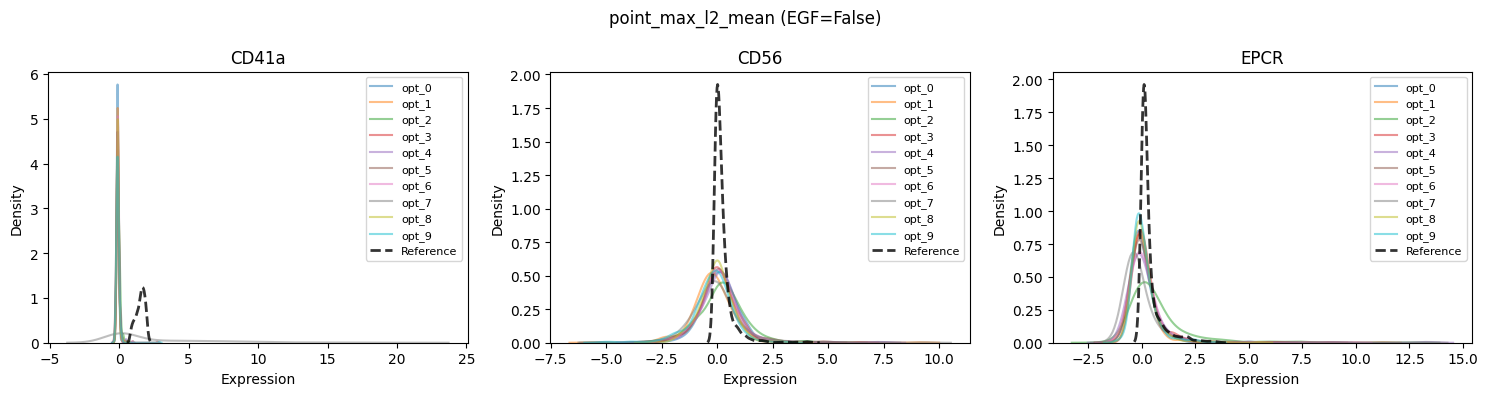

In [78]:
def plot_all_markers_overlay(gen_markers_list, target_info, target_type, use_egf, 
                              feat_names, condition_ids=None, save_dir=None):
    """
    gen_markers_list: list of (n_cells, n_markers) arrays – one per optimized condition
    target_info: 
        - for point targets: (target_values, None) where target_values is (n_markers,) array
        - for population targets: (None, ref_markers) where ref_markers is (n_cells_ref, n_markers)
    condition_ids: optional labels for legend
    """
    n_markers = len(feat_names)
    fig, axes = plt.subplots(1, n_markers, figsize=(5*n_markers, 4))
    if n_markers == 1:
        axes = [axes]
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(gen_markers_list)))
    
    is_population = target_type not in ['max', 'mean', 'median']
    
    for i, marker in enumerate(feat_names):
        ax = axes[i]
        # Overlay KDE for each generated condition
        for j, gen_markers in enumerate(gen_markers_list):
            label = f'Cond {j+1}' if condition_ids is None else condition_ids[j]
            sns.kdeplot(gen_markers[:, i], ax=ax, label=label, 
                        color=colors[j], alpha=0.5, linewidth=1.5)
        
        if is_population:
            # Overlay reference distribution KDE
            ref_markers = target_info[1]   # the reference population matrix
            sns.kdeplot(ref_markers[:, i], ax=ax, label='Reference', 
                        color='black', linestyle='--', linewidth=2, alpha=0.8)
        else:
            # Vertical line at target value
            target_values = target_info[0]
            ax.axvline(target_values[i], color='red', linestyle='--', linewidth=2, 
                       label=f'Target = {target_values[i]:.2f}')
        
        ax.set_title(marker)
        ax.set_xlabel('Expression')
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)
    
    plt.suptitle(f'{target_type} (EGF={use_egf})')
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/{target_type}_EGF{use_egf}_overlay.png", dpi=150)
    plt.show()

# Setup
save_plots = True
plot_dir = "./optimization_plots"
if save_plots:
    import os
    os.makedirs(plot_dir, exist_ok=True)

# Indices of target markers
marker_indices = [all_feat_names.index(m) for m in target_feat_names]

# Reference population matrix (for population targets)
ref_markers = ref_adata[:, target_feat_names].X
if hasattr(ref_markers, 'toarray'):
    ref_markers = ref_markers.toarray()
ref_means = ref_markers.mean(axis=0)   # still needed for point targets? no, point targets use xopt_dict_torch

num_time_steps = 100
solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}
X_true = adata_g.obsm[cell_state_rep]

# Loop over target types and EGF settings
for target_type, egf_dict in opt_samples_dict.items():
    for use_egf, opt_samples in egf_dict.items():
        print("="*80)
        print(f"Target: {target_type}, EGF: {use_egf}")
        
        opt_samples = np.maximum(opt_samples, 0)  # shape (N, D_protocol)
        
        # Forward simulation for all optimized conditions
        fwd_out = generate_with_condition(
            opt_samples,
            forward_model,
            num_time_steps,
            solver_kwargs,
            ct_le,
            num_samples=None,
            noise=noise,
            logger=None,
            n_scatter_feats=6,
        )   # fwd_out["X"] shape: (N, n_cells_per_cond, n_features)
        
        # Collect marker expression for each optimized condition
        gen_markers_list = []
        for idx in range(fwd_out["X"].shape[0]):
            X_gen = fwd_out["X"][idx]   # (n_cells, n_features)
            gen_markers = X_gen[:, marker_indices]   # (n_cells, n_markers)
            gen_markers_list.append(gen_markers)
        
        # Prepare target_info based on target_type
        if target_type in ['max', 'mean', 'median']:
            # Point target: get target values from xopt_dict_torch
            target_full = xopt_dict_torch[target_type]   # shape (1, n_feats) or (n_feats,)
            if target_full.ndim == 1:
                target_full = target_full.reshape(1, -1)
            # target_values should be (n_markers,) – but target_full is a tensor, convert to numpy
            if torch.is_tensor(target_full):
                target_full = target_full.cpu().numpy()
            target_values = target_full[0, marker_indices]   # (n_markers,)
            target_info = (target_values, None)   # tuple: (point_values, None)
        else:
            # Population target: use reference distribution
            target_info = (None, ref_markers)    # tuple: (None, ref_matrix)
        
        # Plot
        plot_all_markers_overlay(
            gen_markers_list, 
            target_info, 
            target_type, 
            use_egf, 
            target_feat_names,
            condition_ids=[f'opt_{i}' for i in range(len(gen_markers_list))],
            save_dir=plot_dir if save_plots else None
        )

### Visualize Condition Space.

In [79]:
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Prepare unique real condition vectors (one per experiment)
# ----------------------------------------------------------------------
# Real condition vectors (assumed shape (n_cells, n_protocol))
real_conds = adata_phi.obsm["condition_concat"]   # or use obs[protocol_columns].values
exp_nums = adata_phi.obs["experiment_number"].values

# Get unique condition per experiment
unique_exps = np.unique(exp_nums)
real_matrix = []
exp_labels = []
for exp in unique_exps:
    mask = exp_nums == exp
    cond = real_conds[mask][0]   # all cells in same exp share the same condition
    real_matrix.append(cond)
    exp_labels.append(exp)
real_matrix = np.array(real_matrix)   # (n_exp, n_protocol)
exp_labels = np.array(exp_labels)


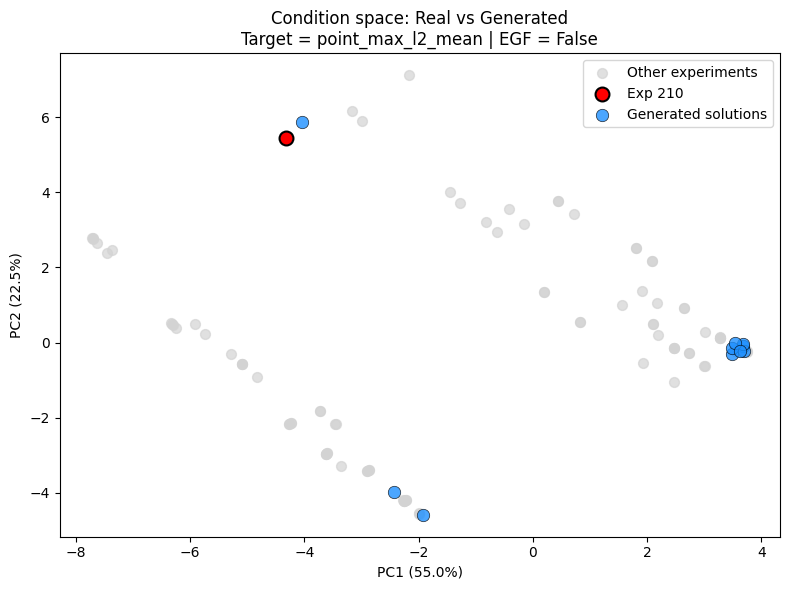

In [80]:
# ----------------------------------------------------------------------
# Plot for each optimization run (no density)
# ----------------------------------------------------------------------
for target_type, inner_dict in opt_samples_dict.items():
    for use_egf, opt_samples in inner_dict.items():
        # opt_samples shape: (N, n_protocol) – N optimized solutions
        opt_samples = np.maximum(opt_samples, 0)
        N_opt = opt_samples.shape[0]
        
        if N_opt == 0:
            print(f"No generated samples for {target_type}, {use_egf}")
            continue
        
        # Combine real + this run's generated
        combined = np.vstack([real_matrix, opt_samples])
        
        # PCA
        pca = PCA(n_components=2)
        try:
            combined_pca = pca.fit_transform(combined)
        except: continue

        n_real = real_matrix.shape[0]
        real_pca = combined_pca[:n_real]
        generated_pca = combined_pca[n_real:]
        
        # Plot
        plt.figure(figsize=(8, 6))
        
        # Real experiments: highlight experiment 210
        is_exp210 = (exp_labels == 210)
        plt.scatter(real_pca[~is_exp210, 0], real_pca[~is_exp210, 1],
                    c='lightgray', label='Other experiments', s=50, alpha=0.7)
        plt.scatter(real_pca[is_exp210, 0], real_pca[is_exp210, 1],
                    c='red', label='Exp 210', s=100, edgecolors='black', linewidth=1.5, zorder=5)
        
        # Generated conditions (uniform colour, no density)
        plt.scatter(generated_pca[:, 0], generated_pca[:, 1],
                    c='dodgerblue', s=80, label='Generated solutions',
                    edgecolors='black', linewidth=0.5, alpha=0.8)
        
        # Labels and title
        plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
        plt.title(f'Condition space: Real vs Generated\nTarget = {target_type} | EGF = {use_egf}')
        plt.legend()
        plt.tight_layout()
        plt.show()

## Run Optimization (WGF Guidance).

### Run WGF Guidance.

In [ ]:
# wgf_opt_samples_dict = {}
# target_types_to_run = ["median"]
# for target_type, opt_dict in loss_fn_dict.items():
#     if target_type not in target_types_to_run:
#         continue
#     print("="*80)
#     print(f"Running Optimization on Target {target_type}")
#     loss_fn = opt_dict["loss_fn"]
#     opt_samples = sample_wgf_guidance(
#         config,
#         loss_fn,
#         prior_cfm,
#         prior_fm,
#         use_langevin=True,
#     )
#     wgf_opt_samples_dict[target_type] = opt_samples
#     print(f"Optimization Finished ({opt_samples.shape=})")

### Visualize Generated Samples.

In [ ]:
# for target_type, opt_samples in wgf_opt_samples_dict.items():
#     opt_samples = np.maximum(opt_samples, 0.0)
#     plt.figure(figsize=(5, 5))
#     g_lgf = sns.clustermap(opt_samples, xticklabels=config.annotation.protocol_columns, figsize=(5, 5))
#     g_lgf.fig.suptitle(f"WGF Target Type: {target_type}", y=1.02)
    

### Tranform Samples Back to their Original Scale.

In [ ]:
# # initialize dataframes
# wgf_raw_opt_df_dict = {}
# wgf_opt_df_dict = {}
# for opt_type, opt_samples in wgf_opt_samples_dict.items():
#     opt_samples = np.maximum(opt_samples, 0)
    
#     wgf_raw_opt_df = pd.DataFrame(opt_samples, columns=config.annotation.protocol_columns)
#     wgf_opt_df = map_df(wgf_raw_opt_df, protocol_transf)

#     wgf_raw_opt_df_dict[opt_type] = wgf_raw_opt_df
#     wgf_opt_df_dict[opt_type] = wgf_opt_df
# wgf_opt_df

### Sakurai Medium.

In [ ]:
# lph_df[lph_df.experiment_number == 210]

### Display Samples.

In [ ]:
# wgf_fwd_res_dict = {}
# num_time_steps = 100
# solver_kwargs = {"method": "euler", "atol": 5e-5, "rtol": 5e-5}
# le_ct = None
# for target_type, opt_samples in wgf_opt_samples_dict.items():
#     opt_samples = np.maximum(opt_samples, 0)
#     fwd_out = generate_with_condition(
#         opt_samples,
#         forward_model,
#         num_time_steps,
#         solver_kwargs,
#         le_ct,
#         num_samples=None,
#         noise=None,
#         logger=None,
#         n_scatter_feats=6,
#     )
#     wgf_fwd_res_dict[target_type] = fwd_out
